In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("../data/processed/features_v2.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values("date")

# Train/test split (same as Stage 3)
split_date = df['date'].quantile(0.8)

train = df[df['date'] < split_date].copy()
test  = df[df['date'] >= split_date].copy()


In [2]:
target = "points"

drop_cols = [
    "raceId", "driverId", "constructorId",
    "date",
    "positionOrder",  # other targets removed
    "avgLapTime_s"
]

features = [col for col in df.columns if col not in drop_cols]

X_train = train[features]
X_test  = test[features]

y_train = train[target]
y_test  = test[target]


In [3]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

preds = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))


MAE: 0.008566822854236975
R2: 0.9999088902882786


In [4]:
test_results = test.copy()
test_results["prediction"] = preds
test_results["error"] = test_results["points"] - test_results["prediction"]
test_results["abs_error"] = np.abs(test_results["error"])


is_DNF
False    0.008567
Name: abs_error, dtype: float64


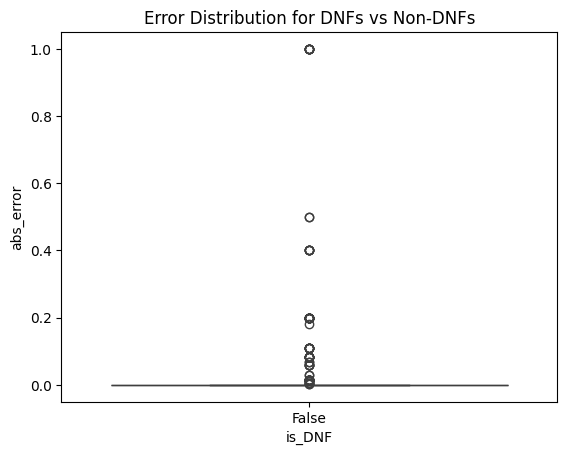

In [5]:
# Define DNF as finishing outside top 20 (adjust if needed)
test_results["is_DNF"] = test_results["positionOrder"] > 20

dnf_errors = test_results.groupby("is_DNF")["abs_error"].mean()
print(dnf_errors)


sns.boxplot(x="is_DNF", y="abs_error", data=test_results)
plt.title("Error Distribution for DNFs vs Non-DNFs")
plt.show()


circuitId
17    0.050000
6     0.033467
13    0.029021
71    0.018012
21    0.015791
14    0.015590
24    0.012564
7     0.011806
80    0.010000
20    0.009917
Name: abs_error, dtype: float64


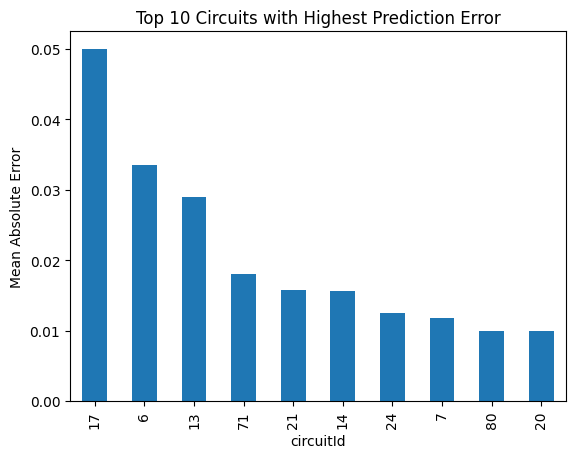

In [6]:
circuit_errors = (
    test_results
    .groupby("circuitId")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(circuit_errors.head(10))

circuit_errors.head(10).plot(kind="bar")
plt.title("Top 10 Circuits with Highest Prediction Error")
plt.ylabel("Mean Absolute Error")
plt.show()


                      feature    importance
3                      points  9.999964e-01
2                        grid  1.780866e-06
7           driver_experience  1.556692e-06
6        constructor_form_avg  1.605435e-07
8    constructor_points_roll5  6.391263e-08
9   driver_circuit_avg_finish  2.553705e-08
4                pitStopCount  1.276073e-08
5             driver_form_avg  1.273897e-08
0                   circuitId  0.000000e+00
1                        year  0.000000e+00
10         circuitType_street  0.000000e+00
11          era_ground_effect  0.000000e+00
12                 era_hybrid  0.000000e+00
13                     era_v8  0.000000e+00


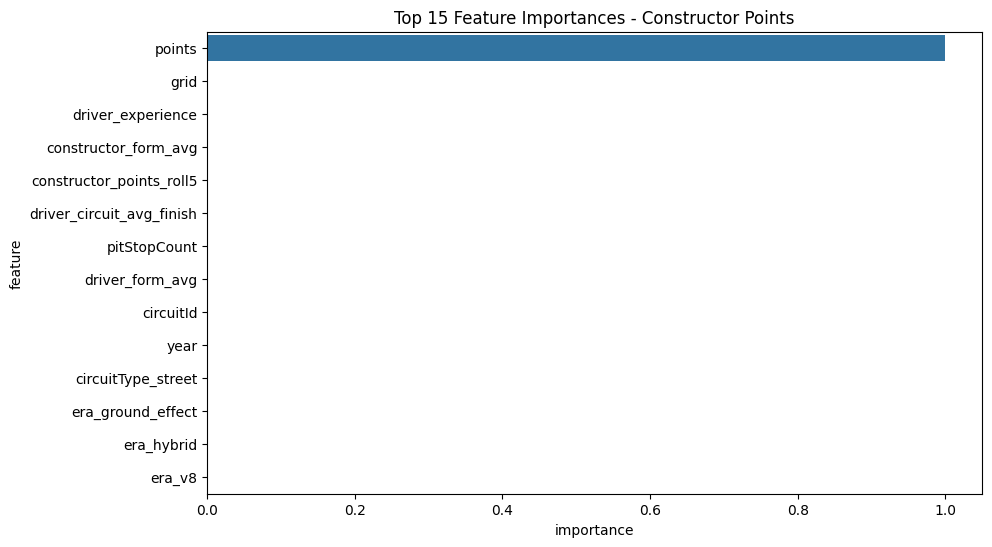

In [7]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feature_importance_df.head(15))


top_n = 15

plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance_df.head(top_n)
)
plt.title("Top 15 Feature Importances - Constructor Points")
plt.show()


In [10]:
%pip install shap

  Using cached shap-0.44.1-cp38-cp38-win_amd64.whl.metadata (25 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.7-py3-none-any.whl.metadata (3.7 kB)
  Using cached numba-0.58.1-cp38-cp38-win_amd64.whl.metadata (2.8 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached llvmlite-0.41.1-cp38-cp38-win_amd64.whl.metadata (4.9 kB)
Using cached shap-0.44.1-cp38-cp38-win_amd64.whl (450 kB)
Using cached slicer-0.0.7-py3-none-any.whl (14 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached numba-0.58.1-cp38-cp38-win_amd64.whl (2.6 MB)
Using cached llvmlite-0.41.1-cp38-cp38-win_amd64.whl (28.1 MB)
Note: you may need to restart the kernel to use updated packages.


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


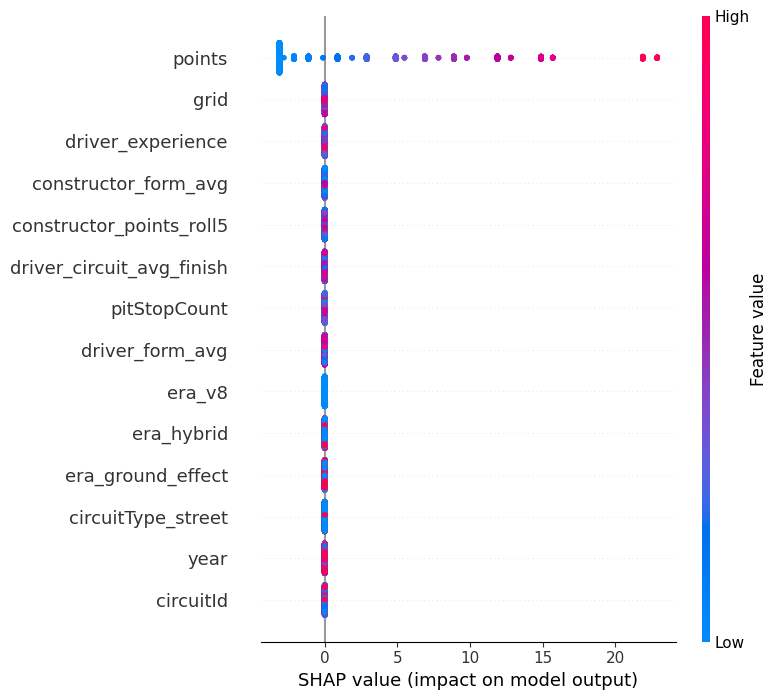

In [11]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


In [12]:
feature_importance_df.tail(10)

,feature,importance
8,constructor_points_roll5,6.391263e-08
9,driver_circuit_avg_finish,2.553705e-08
4,pitStopCount,1.276073e-08
5,driver_form_avg,1.273897e-08
0,circuitId,0.000000e+00
1,year,0.000000e+00
10,circuitType_street,0.000000e+00
11,era_ground_effect,0.000000e+00
12,era_hybrid,0.000000e+00
13,era_v8,0.000000e+00


In [13]:
low_importance_features = feature_importance_df.tail(5)["feature"].tolist()

reduced_features = [f for f in features if f not in low_importance_features]

rf.fit(train[reduced_features], y_train)
new_preds = rf.predict(test[reduced_features])

print("New R2:", r2_score(y_test, new_preds))


New R2: 0.9999088363742591
